# **I. Environment Setup on Google Colab**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!wget -O /content/drive/MyDrive/PFE/models/gb_cosface_backbone.pth http://virutalbuy-public.oss-cn-hangzhou.aliyuncs.com/share/GB-CosFace/models/backbone_paper.pth

--2025-08-08 02:18:11--  http://virutalbuy-public.oss-cn-hangzhou.aliyuncs.com/share/GB-CosFace/models/backbone_paper.pth
Resolving virutalbuy-public.oss-cn-hangzhou.aliyuncs.com (virutalbuy-public.oss-cn-hangzhou.aliyuncs.com)... 118.31.232.219
Connecting to virutalbuy-public.oss-cn-hangzhou.aliyuncs.com (virutalbuy-public.oss-cn-hangzhou.aliyuncs.com)|118.31.232.219|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 261225681 (249M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/PFE/models/gb_cosface_backbone.pth’

/content/drive/MyDr 100%[===================>] 249.12M  13.7MB/s    in 14s     

2025-08-08 02:18:26 (17.5 MB/s) - ‘/content/drive/MyDrive/PFE/models/gb_cosface_backbone.pth’ saved [261225681/261225681]



In [ ]:
# @title
# import torch
# import torch.nn as nn
# from backbone.backbone_def import BackboneFactory

# from tabulate import tabulate

# # ==== Setup ====
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MODEL_PATH = "/content/drive/MyDrive/PFE/models/gb_cosface_backbone.pth"
# BACKBONE_CONF_PATH = "/content/GBCosFace-/configs/backbone_conf.yaml"

# # ==== Load the Backbone ====
# def load_model():
#     backbone_type = "iresnet100"
#     factory = BackboneFactory(backbone_type, BACKBONE_CONF_PATH)
#     model = factory.get_backbone()
#     state_dict = torch.load(MODEL_PATH, map_location="cpu")
#     model.load_state_dict(state_dict)
#     return model.to(DEVICE).eval()

# model = load_model()

# # ==== Recursive module explorer ====
# def flatten_modules(module, parent_name="", level=0):
#     rows = []
#     for name, child in module.named_children():
#         full_name = f"{parent_name}.{name}" if parent_name else name
#         indent = "    " * level
#         row = [f"{indent}{name}", child.__class__.__name__, str(list(child.parameters()))[:50]]
#         rows.append(row)
#         rows += flatten_modules(child, full_name, level + 1)
#     return rows

# # ==== Generate and print hierarchical table ====
# print("\n📐 Hierarchical Model Architecture:\n")
# table = flatten_modules(model)
# headers = ["Layer", "Type", "Details (truncated)"]
# print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

# # ==== Optional: summary using torchsummary ====
# try:
#     from torchsummary import summary
#     print("\n📊 TorchSummary Overview:\n")
#     summary(model, input_size=(3, 112, 112))
# except ImportError:
#     print("\nℹ️ Install torchsummary for detailed summary: pip install torchsummary")


backbone param:
{'params': None}

📐 Hierarchical Model Architecture:

╒════════════╤═════════════╤═════════════════════════════╕
│ Layer      │ Type        │ Details (truncated)         │
╞════════════╪═════════════╪═════════════════════════════╡
│ conv1      │ Conv2d      │ [Parameter containing:      │
│            │             │ tensor([[[[-5.0060e-02, -9. │
├────────────┼─────────────┼─────────────────────────────┤
│ bn1        │ BatchNorm2d │ [Parameter containing:      │
│            │             │ tensor([ 3.1472e-01,  9.488 │
├────────────┼─────────────┼─────────────────────────────┤
│ prelu      │ PReLU       │ [Parameter containing:      │
│            │             │ tensor([ 6.3724e-01,  7.288 │
├────────────┼─────────────┼─────────────────────────────┤
│ layer1     │ Sequential  │ [Parameter containing:      │
│            │             │ tensor([ 8.8754e-02,  7.274 │
├────────────┼─────────────┼─────────────────────────────┤
│ 0          │ IBasicBlock │ [Parameter conta

# **II. Model Definition and Feature Extraction**

In [ ]:
!git clone https://github.com/ilyas-sadiki/GBCosFace-.git
%cd GBCosFace-

Cloning into 'GBCosFace-'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 106 (delta 36), reused 37 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 45.61 KiB | 1.75 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/GBCosFace-


In [ ]:
!pip install -r requirements.txt
!pip install timm

  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 23.3 MB/s eta 0:00:00


## ***1. Training & Validation Script :***

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from backbone.backbone_def import BackboneFactory
from head.head_def import HeadFactory
from loss.loss_def import LossFactory
import os
import yaml

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== Paths (adjust if needed) =====
SPLIT_DATASET_PATH = "/content/drive/MyDrive/PFE/datasets/dataset_split_job2"
TRAIN_PATH = os.path.join(SPLIT_DATASET_PATH, "train", "known")
VAL_PATH = os.path.join(SPLIT_DATASET_PATH, "val", "known")

PRETRAINED_MODEL_PATH = "/content/drive/MyDrive/PFE/models/gb_cosface_backbone.pth"
SAVE_MODEL_PATH = "/content/drive/MyDrive/PFE/models/finetuned_backbone_alpha035_eps01_edited2.pth"
SAVE_PROTOTYPES_PATH = "/content/drive/MyDrive/PFE/models/subcenter_prototypes_alpha035_eps01_edited2.pt"  # NEW

# ===== Dataset setup =====
NUM_CLASSES = len(os.listdir(TRAIN_PATH))

transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=transform)
val_dataset = datasets.ImageFolder(VAL_PATH, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# ===== Load Backbone =====
def load_iresnet100(path):
    backbone_type = "iresnet100"
    backbone_conf_file = "/content/GBCosFace-/configs/backbone_conf.yaml"
    backbone_factory = BackboneFactory(backbone_type, backbone_conf_file)
    backbone = backbone_factory.get_backbone()
    state_dict = torch.load(path, map_location="cpu")
    backbone.load_state_dict(state_dict)
    for name, param in backbone.named_parameters():
        param.requires_grad = any(name.startswith(k) for k in ["layer4", "bn2", "dropout", "fc", "features"])
    return backbone

# ===== Validation =====
def validate(model, head, loss_fn, val_loader):
    model.eval()
    head.eval()
    total_loss = 0.0
    total_samples = 0
    correct = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            embeddings = model(imgs)
            logits = head(embeddings)
            loss = loss_fn(logits, labels)
            if isinstance(loss, dict):
                loss = sum(v for k, v in loss.items() if 'loss' in k)
            total_loss += loss.item() * imgs.size(0)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += imgs.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples
    return avg_loss, accuracy

# ===== Training =====
def train(alpha=0.1, eps=0.1, lr=0.01, optimizer_type='SGD'):
    model = load_iresnet100(PRETRAINED_MODEL_PATH).to(DEVICE)

    # --- Load and update head config ---
    head_conf_file = "/content/GBCosFace-/configs/head_conf.yaml"
    with open(head_conf_file) as f:
        head_conf = yaml.load(f, Loader=yaml.FullLoader)
    head_type = "SubCenterHead" if "SubCenterHead" in head_conf else "BaseHead"
    head_conf[head_type]["num_class"] = NUM_CLASSES
    with open(head_conf_file, "w") as f:
        yaml.dump(head_conf, f)

    head_factory = HeadFactory(head_type, head_conf_file)
    head = head_factory.get_head().to(DEVICE)

    # --- Load and patch loss config ---
    loss_conf_file = "/content/GBCosFace-/configs/loss_conf.yaml"
    with open(loss_conf_file) as f:
        loss_conf = yaml.load(f, Loader=yaml.FullLoader)
    loss_conf['GBCosFace']['alpha'] = alpha
    loss_conf['GBCosFace']['eps'] = eps  # add if using in loss class

    with open(loss_conf_file, "w") as f:
        yaml.dump(loss_conf, f)

    loss_type = "GBCosFace"
    loss_fn = LossFactory(loss_type, loss_conf_file).get_loss()

    params = list(filter(lambda p: p.requires_grad, model.parameters())) + list(head.parameters())
    if optimizer_type == 'SGD':
        optimizer = optim.SGD(params, lr=lr, momentum=0.9, weight_decay=5e-4)
    elif optimizer_type == 'Adam':
        optimizer = optim.Adam(params, lr=lr, weight_decay=5e-4)
    elif optimizer_type == 'AdamW':
        optimizer = optim.AdamW(params, lr=lr, weight_decay=5e-4)
    else:
        raise ValueError(f"Unknown optimizer type: {optimizer_type}")

    best_val_loss = float('inf')

    for epoch in range(10):
        model.train()
        head.train()
        running_loss = 0.0
        for i, (imgs, labels) in enumerate(train_loader):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            embeddings = model(imgs)
            logits = head(embeddings)

            loss_batch = loss_fn(logits, labels)
            loss_val = sum(v for k, v in loss_batch.items() if 'loss' in k) if isinstance(loss_batch, dict) else loss_batch

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()
            running_loss += loss_val.item()

            if i % 10 == 0:
                print(f"[Epoch {epoch+1}/10] Step {i} Training Loss: {loss_val.item():.4f}")

        avg_train_loss = running_loss / len(train_loader)
        val_loss, val_acc = validate(model, head, loss_fn, val_loader)
        print(f"Epoch {epoch+1} Training Loss: {avg_train_loss:.4f} | Validation Loss: {val_loss:.4f} | Validation Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            os.makedirs(os.path.dirname(SAVE_MODEL_PATH), exist_ok=True)
            torch.save(model.state_dict(), SAVE_MODEL_PATH)
            print(f"✅ Saved best model at epoch {epoch+1}")

            if hasattr(head, "weight"):
                torch.save(head.weight.detach().cpu(), SAVE_PROTOTYPES_PATH)
                print(f"💾 Saved subcenter prototypes to: {SAVE_PROTOTYPES_PATH}")


if __name__ == "__main__":

    alpha = 0.35
    eps = 0.1
    lr = 0.001
    optimizer_type = 'SGD'

    print(f"\n🚀 Running with alpha={alpha}, eps={eps}, lr={lr}, optimizer={optimizer_type}")
    train(alpha=alpha, eps=eps, lr=lr, optimizer_type=optimizer_type)



🚀 Running with alpha=0.35, eps=0.1, lr=0.001, optimizer=SGD
backbone param:
{'params': None}
head param:
{'feat_dim': 512, 'k': 3, 'num_class': 119}
loss param:
{'alpha': 0.35, 'eps': 0.1, 'margin': 0.16, 'max_cos_v': 0.7, 'min_cos_v': 0.5, 's': 32, 'update_rate': 0.01}


/content/GBCosFace-/backbone/iresnet.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


[Epoch 1/10] Step 0 Training Loss: 14.5704
[Epoch 1/10] Step 10 Training Loss: 11.0473
[Epoch 1/10] Step 20 Training Loss: 5.8988
[Epoch 1/10] Step 30 Training Loss: 2.9128
[Epoch 1/10] Step 40 Training Loss: 2.1469
[Epoch 1/10] Step 50 Training Loss: 1.4008
[Epoch 1/10] Step 60 Training Loss: 1.6912
[Epoch 1/10] Step 70 Training Loss: 2.1150
[Epoch 1/10] Step 80 Training Loss: 1.3506
[Epoch 1/10] Step 90 Training Loss: 0.9646
[Epoch 1/10] Step 100 Training Loss: 1.1651
[Epoch 1/10] Step 110 Training Loss: 1.5404
Epoch 1 Training Loss: 3.3603 | Validation Loss: 1.2664 | Validation Acc: 0.9842
✅ Saved best model at epoch 1
💾 Saved subcenter prototypes to: /content/drive/MyDrive/PFE/models/subcenter_prototypes_alpha035_eps01_edited2.pt
[Epoch 2/10] Step 0 Training Loss: 1.0900
[Epoch 2/10] Step 10 Training Loss: 0.8132
[Epoch 2/10] Step 20 Training Loss: 1.0027
[Epoch 2/10] Step 30 Training Loss: 0.8451
[Epoch 2/10] Step 40 Training Loss: 0.9581
[Epoch 2/10] Step 50 Training Loss: 1.4630

## ***2. Test Scripts :***

In [ ]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from backbone.backbone_def import BackboneFactory
from head.head_def import HeadFactory
import yaml
from sklearn.metrics.pairwise import cosine_similarity
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Paths ===
SPLIT_DATASET_PATH = "/content/drive/MyDrive/PFE/datasets/dataset_split_job2"
PROBE_KNOWN_PATH = os.path.join(SPLIT_DATASET_PATH, "test", "known")
PROBE_UNKNOWN_PATH = os.path.join(SPLIT_DATASET_PATH, "test", "unknown")

MODEL_PATH = "/content/drive/MyDrive/PFE/models/finetuned_backbone_alpha035_eps01_edited2.pth"
HEAD_CONF_FILE = "/content/GBCosFace-/configs/head_conf.yaml"
SUBCENTER_PROTOTYPES_PATH = "/content/drive/MyDrive/PFE/models/subcenter_prototypes_alpha035_eps01_edited2.pt"

BATCH_SIZE = 64

# === Data transforms (same as training) ===
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

def load_backbone(path):
    backbone_type = "iresnet100"
    backbone_conf_file = "/content/GBCosFace-/configs/backbone_conf.yaml"
    factory = BackboneFactory(backbone_type, backbone_conf_file)
    model = factory.get_backbone()
    state_dict = torch.load(path, map_location="cpu")
    model.load_state_dict(state_dict)
    model.to(DEVICE).eval()
    return model

def load_head():
    with open(HEAD_CONF_FILE) as f:
        head_conf = yaml.load(f, Loader=yaml.FullLoader)
    head_type = "SubCenterHead" if "SubCenterHead" in head_conf else "BaseHead"
    head_conf[head_type]["num_class"] = len(os.listdir(os.path.join(SPLIT_DATASET_PATH, "train", "known")))
    with open(HEAD_CONF_FILE, "w") as f:
        yaml.dump(head_conf, f)
    head_factory = HeadFactory(head_type, HEAD_CONF_FILE)
    head = head_factory.get_head()
    head.to(DEVICE).eval()
    return head

def extract_embeddings(dataloader, model):
    embeddings_list = []
    labels_list = []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(DEVICE)
            embeddings = model(imgs)
            embeddings_list.append(embeddings.cpu().numpy())
            labels_list.append(labels.numpy())
    embeddings_all = np.vstack(embeddings_list)
    labels_all = np.concatenate(labels_list)
    return embeddings_all, labels_all

def extract_embeddings_unlabeled(dataloader, model):
    embeddings_list = []
    with torch.no_grad():
        for imgs, _ in dataloader:
            imgs = imgs.to(DEVICE)
            embeddings = model(imgs)
            embeddings_list.append(embeddings.cpu().numpy())
    embeddings_all = np.vstack(embeddings_list)
    return embeddings_all

# === Load datasets ===
probe_known_dataset = datasets.ImageFolder(PROBE_KNOWN_PATH, transform=transform)
probe_unknown_dataset = datasets.ImageFolder(PROBE_UNKNOWN_PATH, transform=transform)

probe_known_loader = DataLoader(probe_known_dataset, batch_size=BATCH_SIZE, shuffle=False)
probe_unknown_loader = DataLoader(probe_unknown_dataset, batch_size=BATCH_SIZE, shuffle=False)

# === Load model & head ===
print("Loading model and head...")
model = load_backbone(MODEL_PATH)
head = load_head()

# === Load subcenter prototypes (gallery embeddings) ===
print("Loading subcenter prototypes as gallery embeddings...")
subcenter_prototypes = torch.load(SUBCENTER_PROTOTYPES_PATH, map_location="cpu")  # Shape: (num_prototypes, embedding_dim)

# Normalize prototypes to unit length (important for cosine similarity)
gallery_emb = subcenter_prototypes.numpy()
gallery_emb /= np.linalg.norm(gallery_emb, axis=1, keepdims=True)

print(f"Number of prototypes in gallery: {gallery_emb.shape[0]}")

# === Extract probe embeddings ===
print("Extracting probe known embeddings...")
probe_known_emb, probe_known_ids = extract_embeddings(probe_known_loader, model)

print("Extracting probe unknown embeddings...")
probe_unknown_emb = extract_embeddings_unlabeled(probe_unknown_loader, model)

# Normalize probe embeddings to unit length
probe_known_emb /= np.linalg.norm(probe_known_emb, axis=1, keepdims=True)
probe_unknown_emb /= np.linalg.norm(probe_unknown_emb, axis=1, keepdims=True)

# === Match probe embeddings against gallery prototypes ===
print("Computing similarity scores...")
known_sim = cosine_similarity(probe_known_emb, gallery_emb)
unknown_sim = cosine_similarity(probe_unknown_emb, gallery_emb)

# For each probe, get highest similarity and index of prototype
top_scores_known = np.max(known_sim, axis=1)
top_prototype_indices_known = np.argmax(known_sim, axis=1)

top_scores_unknown = np.max(unknown_sim, axis=1)

# === Map prototype index to class id ===
# Assuming prototypes are arranged in order by class (subcenter heads typically do this)
# For example, if each class has M subcenters, then
# class_id = prototype_index // M

# You need to know subcenter count per class from head config
num_classes = len(os.listdir(os.path.join(SPLIT_DATASET_PATH, "train", "known")))

with open(HEAD_CONF_FILE) as f:
    head_conf = yaml.load(f, Loader=yaml.FullLoader)
head_type = "SubCenterHead" if "SubCenterHead" in head_conf else "BaseHead"
if head_type == "SubCenterHead":
    M = head_conf[head_type].get("num_subcenters", 3)  # Adjust if different in your config
else:
    M = 1

predicted_classes = top_prototype_indices_known // M

# === Rank-1 Accuracy ===
rank1_correct = np.sum(probe_known_ids == predicted_classes)
rank1_total = len(probe_known_ids)
rank1_accuracy = rank1_correct / rank1_total
print(f"\n🎯 Rank-1 Accuracy (Known Probes): {rank1_accuracy:.4f}")

# === TPIR @ FPIR ===
def compute_tpir_fpirs(tp_scores, fp_scores, fpir_targets):
    thresholds = np.sort(fp_scores)[::-1]  # Descending
    n_fp_total = len(fp_scores)
    n_tp_total = len(tp_scores)

    results = {}
    for fpir_target in fpir_targets:
        max_fp = int(np.floor(fpir_target * n_fp_total))
        if max_fp == 0:
            max_fp = 1

        thresh_idx = max_fp - 1
        if thresh_idx >= len(thresholds):
            thresh_idx = len(thresholds) - 1

        threshold = thresholds[thresh_idx]

        tp = np.sum(tp_scores >= threshold)
        tpir = tp / n_tp_total
        results[fpir_target] = {
            "threshold": float(threshold),
            "TPIR": float(tpir)
        }
    return results

fpir_targets = [1e-1, 1e-2, 1e-3, 1e-4]
results = compute_tpir_fpirs(top_scores_known, top_scores_unknown, fpir_targets)

print("\n📊 TPIR @ FPIR Results:")
for fpir, res in results.items():
    print(f"  TPIR @ FPIR={fpir:.0e}: {res['TPIR']:.4f} (Threshold: {res['threshold']:.4f})")


### **- Test Script With Visualisations**

=== CMC Evaluation ===
backbone param:
{'params': None}
Extracting embeddings...


/content/GBCosFace-/backbone/iresnet.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


Computing CMC curve...


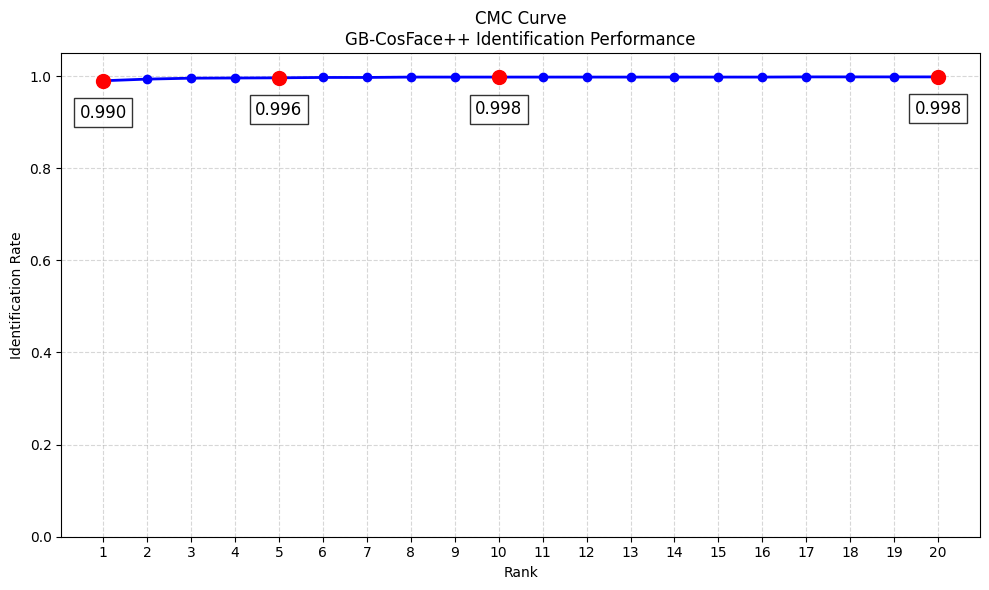


CMC Performance:
Rank-1: 0.9900
Rank-5: 0.9964
Rank-10: 0.9980


In [ ]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from backbone.backbone_def import BackboneFactory
from head.head_def import HeadFactory
import yaml
from sklearn.metrics.pairwise import cosine_similarity
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Paths ===
SPLIT_DATASET_PATH = "/content/drive/MyDrive/PFE/datasets/dataset_split_job2"
PROBE_KNOWN_PATH = os.path.join(SPLIT_DATASET_PATH, "test", "known")
PROBE_UNKNOWN_PATH = os.path.join(SPLIT_DATASET_PATH, "test", "unknown")

MODEL_PATH = "/content/drive/MyDrive/PFE/models/finetuned_backbone_alpha035_eps01_edited.pth"
HEAD_CONF_FILE = "/content/GBCosFace-/configs/head_conf.yaml"
SUBCENTER_PROTOTYPES_PATH = "/content/drive/MyDrive/PFE/models/subcenter_prototypes_alpha035_eps01_edited.pt"

BATCH_SIZE = 64

# === Data transforms ===
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

def load_backbone(path):
    backbone_type = "iresnet100"
    backbone_conf_file = "/content/GBCosFace-/configs/backbone_conf.yaml"
    factory = BackboneFactory(backbone_type, backbone_conf_file)
    model = factory.get_backbone()
    state_dict = torch.load(path, map_location="cpu")
    model.load_state_dict(state_dict)
    model.to(DEVICE).eval()
    return model

def load_head():
    with open(HEAD_CONF_FILE) as f:
        head_conf = yaml.load(f, Loader=yaml.FullLoader)
    head_type = "SubCenterHead" if "SubCenterHead" in head_conf else "BaseHead"
    head_conf[head_type]["num_class"] = len(os.listdir(os.path.join(SPLIT_DATASET_PATH, "train", "known")))
    with open(HEAD_CONF_FILE, "w") as f:
        yaml.dump(head_conf, f)
    head_factory = HeadFactory(head_type, HEAD_CONF_FILE)
    head = head_factory.get_head()
    head.to(DEVICE).eval()
    return head

def extract_embeddings(dataloader, model):
    embeddings_list = []
    labels_list = []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(DEVICE)
            embeddings = model(imgs)
            embeddings_list.append(embeddings.cpu().numpy())
            labels_list.append(labels.numpy())
    return np.vstack(embeddings_list), np.concatenate(labels_list)

def compute_cmc_curve(gallery_emb, gallery_labels, probe_emb, probe_labels, k=20):
    """Compute CMC curve metrics"""
    # Normalize embeddings
    gallery_emb = gallery_emb / np.linalg.norm(gallery_emb, axis=1, keepdims=True)
    probe_emb = probe_emb / np.linalg.norm(probe_emb, axis=1, keepdims=True)

    # Compute similarity matrix
    similarity = probe_emb @ gallery_emb.T

    # Sort gallery items by descending similarity for each probe
    ranked_indices = np.argsort(-similarity, axis=1)
    ranked_labels = gallery_labels[ranked_indices]

    # Calculate identification rates at each rank
    cmc_scores = []
    for rank in range(1, k+1):
        correct = np.any(ranked_labels[:, :rank] == probe_labels[:, np.newaxis], axis=1)
        cmc_scores.append(np.mean(correct))

    return list(range(1, k+1)), cmc_scores

def plot_cmc_curve(ranks, cmc_scores, title="CMC Curve"):
    """Plot the CMC curve with standard formatting"""
    plt.figure(figsize=(10, 6))
    plt.plot(ranks, cmc_scores, 'b-', linewidth=2, marker='o', markersize=6)

    # Highlight key ranks with values
    for rank in [1, 5, 10, 20]:
        if rank <= len(cmc_scores):
            plt.scatter(rank, cmc_scores[rank-1], c='red', s=100, zorder=5)
            plt.text(rank, cmc_scores[rank-1]-0.05,
                    f'{cmc_scores[rank-1]:.3f}',
                    ha='center', va='top', fontsize=12,
                    bbox=dict(facecolor='white', alpha=0.8))

    plt.xlabel('Rank')
    plt.ylabel('Identification Rate')
    plt.title(f'{title}\nGB-CosFace++ Identification Performance')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(ranks)
    plt.ylim([0.0, 1.05])
    plt.tight_layout()
    plt.show()

def evaluate_cmc():
    """Main function to evaluate CMC performance"""
    print("=== CMC Evaluation ===")

    # Load model and data
    model = load_backbone(MODEL_PATH)
    probe_loader = DataLoader(
        datasets.ImageFolder(PROBE_KNOWN_PATH, transform=transform),
        batch_size=BATCH_SIZE, shuffle=False
    )

    # Extract embeddings
    print("Extracting embeddings...")
    probe_emb, probe_labels = extract_embeddings(probe_loader, model)

    # Load gallery (subcenter prototypes)
    gallery_emb = torch.load(SUBCENTER_PROTOTYPES_PATH).numpy()

    # Create gallery labels (assuming prototypes are ordered by class)
    num_classes = len(os.listdir(os.path.join(SPLIT_DATASET_PATH, "train", "known")))
    M = 3  # Number of subcenters per class (adjust if different)
    gallery_labels = np.repeat(np.arange(num_classes), M)

    # Compute CMC
    print("Computing CMC curve...")
    ranks, cmc_scores = compute_cmc_curve(
        gallery_emb, gallery_labels,
        probe_emb, probe_labels,
        k=20
    )

    # Plot results
    plot_cmc_curve(ranks, cmc_scores)

    # Print key metrics
    print("\nCMC Performance:")
    print(f"Rank-1: {cmc_scores[0]:.4f}")
    print(f"Rank-5: {cmc_scores[4]:.4f}")
    print(f"Rank-10: {cmc_scores[9]:.4f}")

    return {
        'ranks': ranks,
        'cmc_scores': cmc_scores,
        'rank1_accuracy': cmc_scores[0],
        'rank5_accuracy': cmc_scores[4],
        'rank10_accuracy': cmc_scores[9]
    }

if __name__ == "__main__":
    cmc_results = evaluate_cmc()